In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datasets import load_dataset

In [3]:
from pathlib import Path 
import os 
import pandas as pd

In [15]:

# EXPERIMENT_DIR_PATH = Path.cwd() / "experiment_data" / "runs"
# BEST_EXPERIMENT_DIR_NAME ="exp_20251127_132944"
# DATA_DIR_PATH = (EXPERIMENT_DIR_PATH / BEST_EXPERIMENT_DIR_NAME).resolve()
# os.listdir(DATA_DIR_PATH)

In [22]:
### Loading from Main Dataset

DATASET_ROOT_DIR = Path.cwd().parent.parent.parent / "dataset" / "final_dataset"
DATASET_ROOT_DIR

PosixPath('/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/dataset/final_dataset')

In [5]:
EXPLORE_DATASET = "diagram_image_to_text"
DATA_PATH = (DATA_DIR_PATH / f"{EXPLORE_DATASET}.parquet").resolve()
DATA_PATH

PosixPath('/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/code_base/which_vlm/dataset_builder/experiment_data/runs/exp_20251127_132944/diagram_image_to_text.parquet')

### Step-1: - Load the Dataset

In [6]:
# Load a local Parquet by pointing to a directory or specific file
ds = load_dataset("parquet", data_files=str(DATA_PATH))
ds

DatasetDict({
    train: Dataset({
        features: ['sample_id', 'run_id', 'timestamp_utc', 'image_path', 'image_bytes_hash', 'prompt_raw', 'prompt_formatted', 'system_prompt', 'source_dataset', 'source_config', 'router_task', 'ground_truth', 'ground_truth_type', 'mc_options', 'source_index', 'img_width', 'img_height', 'img_aspect_ratio', 'img_file_size_bytes', 'txt_prompt_length_chars', 'txt_prompt_length_words', 'txt_question_type', 'txt_has_mc_options', 'model_name', 'model_id', 'response_raw', 'response_parsed', 'response_length_chars', 'response_length_tokens', 'stop_reason', 'error_message', 'is_refusal', 'ok', 'score_exact_match', 'score_exact_match_normalized', 'score_contains_gt', 'score_gt_in_response', 'score_f1', 'score_numeric_match', 'score_mc_letter_match', 'is_correct', 'pred_answer_letter', 'gt_answer_letter', 'input_tokens', 'output_tokens', 'total_tokens', 'latency_ms', 'estimated_cost_usd', 'inference_temperature', 'inference_max_tokens', 'inference_top_p', 'seman

In [7]:
for i in range(0, len(ds['train'].column_names)):
    print(ds['train'].column_names[i] , end='  ')
    if i%5 == 0:
        print()
    

sample_id  
run_id  timestamp_utc  image_path  image_bytes_hash  prompt_raw  
prompt_formatted  system_prompt  source_dataset  source_config  router_task  
ground_truth  ground_truth_type  mc_options  source_index  img_width  
img_height  img_aspect_ratio  img_file_size_bytes  txt_prompt_length_chars  txt_prompt_length_words  
txt_question_type  txt_has_mc_options  model_name  model_id  response_raw  
response_parsed  response_length_chars  response_length_tokens  stop_reason  error_message  
is_refusal  ok  score_exact_match  score_exact_match_normalized  score_contains_gt  
score_gt_in_response  score_f1  score_numeric_match  score_mc_letter_match  is_correct  
pred_answer_letter  gt_answer_letter  input_tokens  output_tokens  total_tokens  
latency_ms  estimated_cost_usd  inference_temperature  inference_max_tokens  inference_top_p  
semantic_f1_precision  semantic_f1_recall  semantic_f1_f1  semantic_f1_gen_statements  semantic_f1_gt_statements  
semantic_f1_matches  semantic_f1_lab

In [8]:
pd.DataFrame.from_dict(ds['train'][0:4]).head()

,sample_id,run_id,timestamp_utc,image_path,image_bytes_hash,prompt_raw,prompt_formatted,system_prompt,source_dataset,source_config,...,semantic_f1_recall,semantic_f1_f1,semantic_f1_gen_statements,semantic_f1_gt_statements,semantic_f1_matches,semantic_f1_labels,glider_score,glider_reasoning,glider_highlight,glider_raw_output
0,diagram_image_to_text_00000_738081ac2cb98f5a,exp_20251127_132944,2025-11-27T18:29:54.672825,None,738081ac2cb98f5a,"Dissect the diagram, highlighting the interact...",None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,None,None,None,None,None,4,- The model's output is semantically correct a...,"[Are you thirsty?, Yes, Take water, No, Don't ...",<reasoning>\n- The model's output is semantic...
1,diagram_image_to_text_00001_cbe01c09e19aa23d,exp_20251127_132944,2025-11-27T18:29:55.917347,None,cbe01c09e19aa23d,"Interpret the system depicted in the diagram, ...",None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,None,None,None,None,None,4,- The model's output is semantically correct a...,"[Start, Input, Area = Width * Height, Height, ...",<reasoning>\n- The model's output is semantic...
2,diagram_image_to_text_00002_36610fa6154d4add,exp_20251127_132944,2025-11-27T18:29:57.139260,None,36610fa6154d4add,Review the diagram and comment on the linkage ...,None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,None,None,None,None,None,0,- The model's output does not provide any info...,"[does not provide, incomplete, lacks, no menti...",<reasoning>\n- The model's output does not pr...
3,diagram_image_to_text_00003_e03f0ca8b71f5e66,exp_20251127_132944,2025-11-27T18:29:58.982631,None,e03f0ca8b71f5e66,Delineate the roles of the components within t...,None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,None,None,None,None,None,4,- The model's answer is semantically correct a...,"[flowchart, decision-making, Is it food?, Yes,...",<reasoning>\n- The model's answer is semantic...


In [9]:
pd.DataFrame(ds['train'])
# ['sample_id'][0].split(EXPLORE_DATASET+"_", 1)[1]

,sample_id,run_id,timestamp_utc,image_path,image_bytes_hash,prompt_raw,prompt_formatted,system_prompt,source_dataset,source_config,...,semantic_f1_recall,semantic_f1_f1,semantic_f1_gen_statements,semantic_f1_gt_statements,semantic_f1_matches,semantic_f1_labels,glider_score,glider_reasoning,glider_highlight,glider_raw_output
0,diagram_image_to_text_00000_738081ac2cb98f5a,exp_20251127_132944,2025-11-27T18:29:54.672825,None,738081ac2cb98f5a,"Dissect the diagram, highlighting the interact...",None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,None,None,None,None,None,4,- The model's output is semantically correct a...,"[Are you thirsty?, Yes, Take water, No, Don't ...",<reasoning>\n- The model's output is semantic...
1,diagram_image_to_text_00001_cbe01c09e19aa23d,exp_20251127_132944,2025-11-27T18:29:55.917347,None,cbe01c09e19aa23d,"Interpret the system depicted in the diagram, ...",None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,None,None,None,None,None,4,- The model's output is semantically correct a...,"[Start, Input, Area = Width * Height, Height, ...",<reasoning>\n- The model's output is semantic...
2,diagram_image_to_text_00002_36610fa6154d4add,exp_20251127_132944,2025-11-27T18:29:57.139260,None,36610fa6154d4add,Review the diagram and comment on the linkage ...,None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,None,None,None,None,None,0,- The model's output does not provide any info...,"[does not provide, incomplete, lacks, no menti...",<reasoning>\n- The model's output does not pr...
3,diagram_image_to_text_00003_e03f0ca8b71f5e66,exp_20251127_132944,2025-11-27T18:29:58.982631,None,e03f0ca8b71f5e66,Delineate the roles of the components within t...,None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,None,None,None,None,None,4,- The model's answer is semantically correct a...,"[flowchart, decision-making, Is it food?, Yes,...",<reasoning>\n- The model's answer is semantic...
4,diagram_image_to_text_00004_fef1d1909c3d5bd3,exp_20251127_132944,2025-11-27T18:30:00.698289,None,fef1d1909c3d5bd3,Delineate the roles of the components within t...,None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,None,None,None,None,None,4,- The model's output is semantically correct a...,"[initialize, weights, biases, perform, operati...",<reasoning>\n- The model's output is semantic...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,diagram_image_to_text_00291_aa48e0cefc6747d7,exp_20251127_132944,2025-11-27T18:49:58.363786,None,aa48e0cefc6747d7,"Dissect the diagram, highlighting the interact...",None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,None,None,None,None,None,5,- The model's output accurately reflects the g...,"[Initialization, System update, Time-updating,...",<reasoning>\n- The model's output accurately ...
1496,diagram_image_to_text_00292_efaf28a2de7afd6d,exp_20251127_132944,2025-11-27T18:50:12.409712,None,efaf28a2de7afd6d,Narrate the process illustrated by the diagram...,None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,None,None,None,None,None,5,- The model's output accurately reflects the g...,"[Start, Read, Update value, Print, X > 0, YES,...",<reasoning>\n- The model's output accurately ...
1497,diagram_image_to_text_00293_0606aba958608b08,exp_20251127_132944,2025-11-27T18:50:27.985984,None,0606aba958608b08,Detail the hierarchical structure of the compo...,None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,None,None,None,None,None,4,- The model's answer is semantically correct a...,"[flowchart, decision-making, nodes, process, r...",<reasoning>\n- The model's answer is semantic...
1498,diagram_image_to_text_00294_4bb0e1fa8a1a25aa,exp_20251127_132944,2025-11-27T18:50:44.676902,None,4bb0e1fa8a1a25aa,Break down the diagram into its components and...,None,None,cauldron_diagram_image_to_text,diagram_image_to_text,...,None,No

### Step-2: Compare model responses for a single Cauldron image


In [10]:
from check_data_utils import (
    load_run_records,
    build_same_image_dataframe,
    fetch_cauldron_image,
)

run_df = load_run_records(DATA_DIR_PATH, subset=[EXPLORE_DATASET])
same_image_df = build_same_image_dataframe(run_df)
print(same_image_df.columns)
print(f'Samples with >=2 model responses: {len(same_image_df):,}')
same_image_df[['sample_id', 'n_models', 'n_correct', 'models']].head()


Index(['sample_id', 'image_bytes_hash', 'source_config', 'source_index',
       'router_task', 'prompt_raw', 'ground_truth', 'n_models', 'n_correct',
       'models', 'model_outcomes', 'model_records'],
      dtype='object')
Samples with >=2 model responses: 300


,sample_id,n_models,n_correct,models
0,diagram_image_to_text_00000_738081ac2cb98f5a,5,0,"[deepseek-ocr, gemma-3-27b, qwen2.5-vl-3b, qwe..."
1,diagram_image_to_text_00001_cbe01c09e19aa23d,5,1,"[deepseek-ocr, gemma-3-27b, qwen2.5-vl-3b, qwe..."
2,diagram_image_to_text_00002_36610fa6154d4add,5,0,"[deepseek-ocr, gemma-3-27b, qwen2.5-vl-3b, qwe..."
3,diagram_image_to_text_00003_e03f0ca8b71f5e66,5,0,"[deepseek-ocr, gemma-3-27b, qwen2.5-vl-3b, qwe..."
4,diagram_image_to_text_00004_fef1d1909c3d5bd3,5,0,"[deepseek-ocr, gemma-3-27b, qwen2.5-vl-3b, qwe..."


In [11]:
same_image_df.columns

Index(['sample_id', 'image_bytes_hash', 'source_config', 'source_index',
       'router_task', 'prompt_raw', 'ground_truth', 'n_models', 'n_correct',
       'models', 'model_outcomes', 'model_records'],
      dtype='object')

In [12]:
focus_row = same_image_df.iloc[0]
model_df = pd.DataFrame(focus_row['model_records'])
print(focus_row['sample_id'], focus_row['image_bytes_hash'])
display(model_df[['model_name','router_task','is_correct','score_f1','glider_score','latency_ms']])
# model_df[['model_name','prompt_raw','response_raw','glider_reasoning']]


diagram_image_to_text_00000_738081ac2cb98f5a 738081ac2cb98f5a


,model_name,router_task,is_correct,score_f1,glider_score,latency_ms
0,deepseek-ocr,diagram_captioning,False,0.200000,4,435.962200
1,gemma-3-27b,diagram_captioning,False,0.261682,4,8491.960049
2,qwen2.5-vl-3b,diagram_captioning,False,0.276596,4,1402.608871
3,qwen2.5-vl-7b,diagram_captioning,False,0.288889,4,2021.623135
4,qwen3-vl-8b-thinking,diagram_captioning,False,0.218750,4,3402.161837


sample_id                diagram_image_to_text_00000_738081ac2cb98f5a
image_bytes_hash                                     738081ac2cb98f5a
source_config                                   diagram_image_to_text
source_index                                                        0
router_task                                        diagram_captioning
prompt_raw          Dissect the diagram, highlighting the interact...
ground_truth        If Are you thirsty? is Yes then Take water and...
n_models                                                            5
n_correct                                                           0
models              [deepseek-ocr, gemma-3-27b, qwen2.5-vl-3b, qwe...
model_outcomes      [{'model_name': 'deepseek-ocr', 'model_id': 'd...
model_records       [{'sample_id': 'diagram_image_to_text_00000_73...
Name: 0, dtype: object

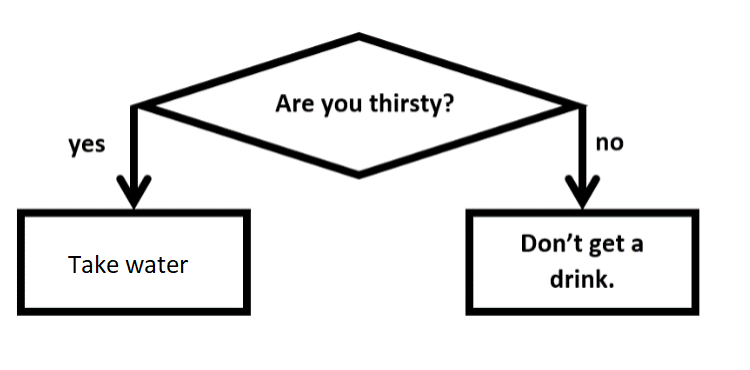

In [13]:
from IPython.display import display
display(focus_row)

image, sample_dict = fetch_cauldron_image(
    focus_row['source_config'],
    focus_row['source_index'],
    image_hash=focus_row['image_bytes_hash'],
)
display(image)


### Step-3: Pivot model responses per image


In [14]:
pivot_records = (
    same_image_df[['sample_id', 'prompt_raw', 'ground_truth', 'model_records']]
    .explode('model_records')
    .reset_index(drop=True)
)
expanded = pivot_records['model_records'].apply(pd.Series)
expanded = expanded.loc[:, ~expanded.columns.duplicated()]
pivot_records = pd.concat(
    [
        pivot_records.drop(columns=['model_records']),
        expanded,
    ],
    axis=1,
)
pivot_records = pivot_records.loc[:, ~pivot_records.columns.duplicated()]

pivot_df = (
    pivot_records
    .pivot_table(
        index=['sample_id', 'prompt_raw', 'ground_truth'],
        columns='model_name',
        values=['response_raw', 'glider_score', 'is_correct'],
        aggfunc='first',
    )
    .sort_index(axis=1)
)
pivot_df.columns = [f"{metric}/{model}" for metric, model in pivot_df.columns]
pivot_df = pivot_df.reset_index()
pivot_df.head()


,sample_id,prompt_raw,ground_truth,glider_score/deepseek-ocr,glider_score/gemma-3-27b,glider_score/qwen2.5-vl-3b,glider_score/qwen2.5-vl-7b,glider_score/qwen3-vl-8b-thinking,is_correct/deepseek-ocr,is_correct/gemma-3-27b,is_correct/qwen2.5-vl-3b,is_correct/qwen2.5-vl-7b,is_correct/qwen3-vl-8b-thinking,response_raw/deepseek-ocr,response_raw/gemma-3-27b,response_raw/qwen2.5-vl-3b,response_raw/qwen2.5-vl-7b,response_raw/qwen3-vl-8b-thinking
0,diagram_image_to_text_00000_738081ac2cb98f5a,"Dissect the diagram, highlighting the interact...",If Are you thirsty? is Yes then Take water and...,4,4,4,4,4,False,False,False,False,False,<table>Are you thirsty?YesNoTake waterDon't ge...,"Here's a dissection of the diagram, highlighti...",The diagram is a simple flowchart that present...,The diagram is a flowchart that outlines a dec...,"Got it, let's dissect this flowchart. First, t..."
1,diagram_image_to_text_00001_cbe01c09e19aa23d,"Interpret the system depicted in the diagram, ...",Start is connected with Input which is then co...,4,4,5,5,4,True,False,False,False,False,```graphviz\n Start --> Input\n Input --> Ar...,Here's an interpretation of the system depicte...,The diagram represents a flowchart that outlin...,The provided flowchart outlines a simple proce...,"Got it, let's try to figure out what this flow..."
2,diagram_image_to_text_00002_36610fa6154d4add,Review the diagram and comment on the linkage ...,Start is connected with Initialize which is th...,0,4,4,5,4,False,False,False,False,False,,Here's a review of the diagram's linkage and f...,The flowchart you provided outlines a basic pr...,The provided flowchart outlines a sequence of ...,"Got it, let's analyze this flowchart. First, I..."
3,diagram_image_to_text_00003_e03f0ca8b71f5e66,Delineate the roles of the components within t...,If Is it food? is No then Try to eat it immedi...,4,4,4,5,4,False,False,False,False,False,The provided diagram illustrates a flowchart t...,Here's a breakdown of the roles of the compone...,The diagram is a flowchart that outlines a dec...,The diagram is a simple flowchart that outline...,"Got it, let's break down this flowchart. First..."
4,diagram_image_to_text_00004_fef1d1909c3d5bd3,Delineate the roles of the components within t...,Begin is connected with Initialize weights and...,4,5,4,4,4,False,False,False,False,False,```graphviz\n Begin\n Initialize weights and...,Here's a breakdown of the roles of each compon...,The flowchart you've provided outlines the bas...,The flowchart in the image represents a basic ...,"Got it, let's try to figure out the roles of e..."
